Author: Krish

In [2]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [8]:
data_path = Path.home() / "CAR Data"
print("Exists?", data_path.exists())

Exists? True


### User input ends

### Reading all filenames in the data folder

In [13]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [16]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [40]:
df_main["Activity Start Timestamp"] = pd.to_datetime(
    df_main["Activity Start Timestamp"],
    format="%Y/%m/%d %I:%M:%S %p",
    errors="coerce"
)


In [48]:
#df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    #lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [42]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
hour                                 int32
dtype: object

In [44]:
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

In [46]:
df_main.to_csv("combined_calls_CAR.csv", index=False)

## **Front Desk Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df_main = pd.read_csv("combined_calls_CAR.csv")
df_main['Activity Start Timestamp'] = pd.to_datetime(df_main['Activity Start Timestamp'])
df_main = df_main.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total rows: {len(df_main):,}")
print(f"Unique sessions: {df_main['Contact Session ID'].nunique():,}")
print(f"Date range: {df_main['Activity Start Timestamp'].min()} to {df_main['Activity Start Timestamp'].max()}")

print("\n" + "=" * 60)
print("FRONT DESK ACTIVITY DETECTION")
print("=" * 60)

# Check for FrontDeskTransfer activities
front_desk_activities = df_main[df_main['Activity Name'].str.contains('FrontDesk', case=False, na=False)]
print(f"\nRows with 'FrontDesk' in Activity Name: {len(front_desk_activities):,}")
print(f"Unique sessions: {front_desk_activities['Contact Session ID'].nunique():,}")

# Check Activity Name values
print("\nUnique Activity Names containing 'FrontDesk':")
print(front_desk_activities['Activity Name'].value_counts())

# Check Queue Name
front_desk_queue = df_main[df_main['Queue Name'].str.contains('Front Desk', case=False, na=False)]
print(f"\nRows with 'Front Desk' in Queue Name: {len(front_desk_queue):,}")
print(f"Unique Queue Names: {front_desk_queue['Queue Name'].unique()}")

print("\n" + "=" * 60)
print("SAMPLE CALL JOURNEY (First Front Desk Session)")
print("=" * 60)

# Show a sample journey
if len(front_desk_activities) > 0:
    sample_session = front_desk_activities['Contact Session ID'].iloc[0]
    sample_journey = df_main[df_main['Contact Session ID'] == sample_session]
    print(f"\nSession ID: {sample_session}")
    print(f"Total activities: {len(sample_journey)}")
    print("\nCall flow:")
    for idx, row in sample_journey.iterrows():
        print(f"  {row['Activity Start Timestamp'].strftime('%H:%M:%S')} - {row['Activity Name']}")
        if pd.notna(row['Queue Name']):
            print(f"    └─ Queue: {row['Queue Name']}")

/var/folders/0k/z0xdft5548x02pfzbdd0x6w40000gn/T/ipykernel_68850/1085902591.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_main = pd.read_csv("combined_calls_CAR.csv")


DATASET OVERVIEW
Total rows: 3,328,626
Unique sessions: 248,442
Date range: 2024-04-07 00:32:12 to 2025-09-30 22:23:35

FRONT DESK ACTIVITY DETECTION

Rows with 'FrontDesk' in Activity Name: 17,893
Unique sessions: 17,893

Unique Activity Names containing 'FrontDesk':
Activity Name
FrontDeskTransfer1    7912
FrontDeskTransfer2    6895
FrontDeskTransfer     2545
FrontDeskTransfer3     541
Name: count, dtype: int64

Rows with 'Front Desk' in Queue Name: 60,234
Unique Queue Names: ['Front Desk Transfer']

SAMPLE CALL JOURNEY (First Front Desk Session)

Session ID: 00011655-35de-476f-9a8c-dd48ed4d914a
Total activities: 13

Call flow:
  14:39:01 - nan
  14:39:01 - nan
  14:39:01 - LanguageSelectionMenu
  14:39:01 - nan
  14:39:20 - LanguageSelectionMenu
  14:39:30 - MainMenu
  14:40:43 - HelpWithLegalorOtherReasonMenu
  14:40:53 - MainMenu
  14:42:05 - HelpWithLegalorOtherReasonMenu
  14:42:14 - FrontDeskTransfer2
  14:42:16 - nan
    └─ Queue: Front Desk Transfer
  14:42:20 - nan
    └─ Qu

In [3]:
# Create a function to identify which FrontDeskTransfer variant was used
def identify_front_desk_type(session_df):
    """Identify which FrontDeskTransfer (1, 2, or 3) was used"""
    fd_activities = session_df[session_df['Activity Name'].str.contains('FrontDeskTransfer', case=False, na=False)]
    
    if len(fd_activities) == 0:
        return None
    
    # Get the most common (or first) front desk transfer type
    fd_type = fd_activities['Activity Name'].iloc[0]
    return fd_type

# Mark sessions that went through front desk
sessions_with_fd = df_main[
    df_main['Activity Name'].str.contains('FrontDesk', case=False, na=False)
]['Contact Session ID'].unique()

print(f"Sessions with Front Desk interaction: {len(sessions_with_fd):,}")
print(f"Percentage of all sessions: {len(sessions_with_fd) / df_main['Contact Session ID'].nunique() * 100:.1f}%")

# Create a dataframe with one row per session that touched front desk
front_desk_sessions = []

for session_id in sessions_with_fd:
    session_df = df_main[df_main['Contact Session ID'] == session_id].copy()
    
    fd_type = identify_front_desk_type(session_df)
    
    front_desk_sessions.append({
        'Contact Session ID': session_id,
        'Front Desk Type': fd_type,
        'Total Activities': len(session_df),
        'First Activity': session_df.iloc[0]['Activity Name'],
        'Last Activity': session_df.iloc[-1]['Activity Name'],
        'Duration_Minutes': (session_df.iloc[-1]['Activity Start Timestamp'] - 
                            session_df.iloc[0]['Activity Start Timestamp']).total_seconds() / 60
    })

df_fd_sessions = pd.DataFrame(front_desk_sessions)

print("\n" + "=" * 60)
print("FRONT DESK TYPE DISTRIBUTION")
print("=" * 60)
print(df_fd_sessions['Front Desk Type'].value_counts())

Sessions with Front Desk interaction: 17,893
Percentage of all sessions: 7.2%

FRONT DESK TYPE DISTRIBUTION
Front Desk Type
FrontDeskTransfer1    7912
FrontDeskTransfer2    6895
FrontDeskTransfer     2545
FrontDeskTransfer3     541
Name: count, dtype: int64


In [22]:
# ============================================================
# COMPLETE FRONT DESK RETURN ANALYSIS (on all data) 
# ============================================================

print("=" * 70)
print("🎯 FRONT DESK RETURN ANALYSIS")
print("=" * 70)

# ============================================================
# STEP 0: Clean up any existing columns from previous runs
# ============================================================

columns_to_remove = ['is_front_desk', 'is_main_menu_return', 'activity_sequence', 
                     'first_fd_position', 'after_fd', 'is_any_menu']

for col in columns_to_remove:
    if col in df_main.columns:
        df_main = df_main.drop(columns=[col])
        print(f"   ✓ Removed existing column: {col}")

# ============================================================
# STEP 1: Prepare the data
# ============================================================

print("\n📊 Step 1: Preparing data...")

# Ensure data is sorted
df_main = df_main.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Mark front desk activities
df_main['is_front_desk'] = df_main['Activity Name'].str.contains('FrontDesk', case=False, na=False)

# Mark main menu EPs
main_menu_ep_names = [
    'Main Number Telephony EP',
    'Farmworker Main Number Telephony EP'
]
df_main['is_main_menu_return'] = df_main['EP Name'].isin(main_menu_ep_names)

# Create activity sequence number within each session
df_main['activity_sequence'] = df_main.groupby('Contact Session ID').cumcount()

print(f"   ✓ Total rows: {len(df_main):,}")
print(f"   ✓ Unique sessions: {df_main['Contact Session ID'].nunique():,}")
print(f"   ✓ Front desk activities: {df_main['is_front_desk'].sum():,}")
print(f"   ✓ Main menu activities: {df_main['is_main_menu_return'].sum():,}")

# ============================================================
# STEP 2: Find front desk sessions and positions
# ============================================================

print("\n📍 Step 2: Finding front desk positions...")

# Get the position (sequence number) of the FIRST front desk activity in each session
fd_positions = df_main[df_main['is_front_desk']].groupby('Contact Session ID')['activity_sequence'].first()
fd_positions.name = 'first_fd_position'

# Get list of sessions that went through front desk
sessions_with_fd = fd_positions.index.tolist()

print(f"   ✓ Sessions with front desk: {len(sessions_with_fd):,}")

# Merge the front desk position back to main dataframe
df_main = df_main.merge(
    fd_positions.reset_index(), 
    on='Contact Session ID', 
    how='left'
)

# Mark activities that occur AFTER the first front desk activity
df_main['after_fd'] = (
    (df_main['first_fd_position'].notna()) & 
    (df_main['activity_sequence'] > df_main['first_fd_position'])
)

print(f"   ✓ Activities marked as 'after_fd': {df_main['after_fd'].sum():,}")

# ============================================================
# STEP 3: Detect main menu returns
# ============================================================

print("\n🔄 Step 3: Detecting main menu returns...")

# Find sessions where they went to main menu AFTER front desk
main_menu_returns = df_main[
    (df_main['after_fd'] == True) & 
    (df_main['is_main_menu_return'] == True)
]['Contact Session ID'].unique()

print(f"\n📊 RESULTS:")
print(f"   Total Front Desk Sessions: {len(sessions_with_fd):,}")
print(f"   Sessions returning to Main Menu: {len(main_menu_returns):,}")
if len(sessions_with_fd) > 0:
    return_rate = len(main_menu_returns) / len(sessions_with_fd) * 100
    print(f"   Return Rate: {return_rate:.1f}%")
else:
    return_rate = 0
    print(f"   Return Rate: 0.0%")

# ============================================================
# STEP 4: Build summary dataframe
# ============================================================

print("\n📋 Step 4: Building summary dataframe...")

# Get the front desk type for each session
fd_types = df_main[df_main['is_front_desk']].groupby('Contact Session ID')['Activity Name'].first()

# Create summary dataframe
df_return_analysis = pd.DataFrame({
    'Contact Session ID': sessions_with_fd,
    'Front Desk Type': [fd_types.get(sid) for sid in sessions_with_fd],
    'Returned to Main Menu': [sid in main_menu_returns for sid in sessions_with_fd]
})

print(f"   ✓ Summary dataframe created with {len(df_return_analysis):,} rows")

# ============================================================
# STEP 5: Analyze by front desk type
# ============================================================

print("\n" + "=" * 70)
print("📈 RETURN RATE BY FRONT DESK TYPE")
print("=" * 70)

return_by_type = df_return_analysis.groupby('Front Desk Type').agg({
    'Returned to Main Menu': ['count', 'sum', lambda x: f"{x.mean()*100:.1f}%"]
})
return_by_type.columns = ['Total', 'Returns', 'Return_Rate']
print(return_by_type)

# ============================================================
# STEP 6: Which main menu do they return to?
# ============================================================

if len(main_menu_returns) > 0:
    print("\n" + "=" * 70)
    print("🔍 WHICH MAIN MENU DO THEY RETURN TO?")
    print("=" * 70)
    
    # For sessions that returned, get the specific EP Name they returned to
    returned_menu_info = df_main[
        (df_main['Contact Session ID'].isin(main_menu_returns)) &
        (df_main['after_fd'] == True) &
        (df_main['is_main_menu_return'] == True)
    ].groupby('Contact Session ID')['EP Name'].first()
    
    # Add to summary dataframe
    df_return_analysis['Menu Returned To'] = df_return_analysis['Contact Session ID'].map(returned_menu_info)
    
    print("\nDestination after Front Desk:")
    menu_dest_counts = df_return_analysis['Menu Returned To'].value_counts(dropna=False)
    for menu, count in menu_dest_counts.items():
        pct = count / len(main_menu_returns) * 100
        print(f"   {menu:<45} {count:>6,} ({pct:.1f}%)")
    
    # Cross-tab: Which FD type goes to which menu?
    print("\n" + "=" * 70)
    print("🔀 FRONT DESK TYPE → MENU DESTINATION")
    print("=" * 70)
    
    cross_tab = pd.crosstab(
        df_return_analysis['Front Desk Type'], 
        df_return_analysis['Menu Returned To'],
        margins=True
    )
    print(cross_tab)

# ============================================================
# STEP 7: Broader analysis - ALL menu returns
# ============================================================

print("\n" + "=" * 70)
print("🤔 BROADER ANALYSIS: Returns to ANY Menu Type")
print("=" * 70)

# Define all menu EPs
all_menu_ep_names = [
    'Main Number Telephony EP',
    'Farmworker Main Number Telephony EP',
    'Legal Menu Telephony EP',
    'Pre-Legal Menu Seniors Menu Telephony EP',
    'Other Legal Menu Telephony EP',
    'Legal Housing Menu Telephony EP',
    'Legal Family Menu Telephony EP',
    'Legal Benefits Menu Telephony EP',
    'Legal HIV Menu Telephony EP',
    'Legal Immigration Menu Telephony EP',
    'Legal Employment Menu Telephony EP'
]

df_main['is_any_menu'] = df_main['EP Name'].isin(all_menu_ep_names)

any_menu_returns = df_main[
    (df_main['after_fd'] == True) & 
    (df_main['is_any_menu'] == True)
]['Contact Session ID'].unique()

print(f"Sessions going to ANY menu after FD: {len(any_menu_returns):,}")
if len(sessions_with_fd) > 0:
    print(f"Rate: {len(any_menu_returns) / len(sessions_with_fd) * 100:.1f}%")

# What menus do they go to?
print("\nAll menu destinations after Front Desk:")
menu_destinations = df_main[
    (df_main['Contact Session ID'].isin(any_menu_returns)) &
    (df_main['after_fd'] == True) &
    (df_main['is_any_menu'] == True)
].groupby('Contact Session ID')['EP Name'].first().value_counts()

for menu, count in menu_destinations.items():
    pct = count / len(any_menu_returns) * 100
    print(f"   {menu:<45} {count:>6,} ({pct:.1f}%)")

# ============================================================
# STEP 8: Sample journeys (FIXED - HANDLES NaN VALUES)
# ============================================================

print("\n" + "=" * 70)
print("📋 SAMPLE JOURNEYS - Calls that returned to Main Menu")
print("=" * 70)

if len(main_menu_returns) > 0:
    # Show 3 example journeys
    for i, session_id in enumerate(list(main_menu_returns)[:3], 1):
        print(f"\n{'─'*70}")
        print(f"Example {i}: Session {session_id}")
        print(f"{'─'*70}")
        
        session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
        
        for idx, row in session_df.iterrows():
            timestamp = row['Activity Start Timestamp'].strftime('%H:%M:%S')
            ep = str(row['EP Name'])[:35] if pd.notna(row['EP Name']) else 'N/A'
            activity = str(row['Activity Name'])[:40] if pd.notna(row['Activity Name']) else 'N/A'
            
            # Add markers
            if row['is_front_desk']:
                marker = "🚪 [FRONT DESK]"
            elif row['is_main_menu_return']:
                marker = "🔄 [RETURNED TO MAIN]"
            else:
                marker = ""
            
            print(f"  {timestamp} | {ep:<35} | {activity:<40} {marker}")
else:
    print("\n⚠️  No sessions returned to main menu after front desk")

# ============================================================
# STEP 9: Export results
# ============================================================

print("\n" + "=" * 70)
print("💾 EXPORTING RESULTS")
print("=" * 70)

# Export main analysis
df_return_analysis.to_csv('front_desk_return_analysis.csv', index=False)
print("✓ Exported: front_desk_return_analysis.csv")

# Export detailed journey for returns (if any exist)
if len(main_menu_returns) > 0:
    return_journeys_detailed = df_main[
        df_main['Contact Session ID'].isin(main_menu_returns)
    ][['Contact Session ID', 'Activity Start Timestamp', 'EP Name', 
       'Activity Name', 'Queue Name', 'is_front_desk', 'is_main_menu_return', 
       'activity_sequence', 'after_fd']].sort_values(['Contact Session ID', 'Activity Start Timestamp'])
    
    return_journeys_detailed.to_csv('return_journey_details.csv', index=False)
    print("✓ Exported: return_journey_details.csv")

# ============================================================
# STEP 10: Final summary
# ============================================================

print("\n" + "=" * 70)
print("📊 FINAL SUMMARY")
print("=" * 70)

summary_stats = {
    'Total Sessions': df_main['Contact Session ID'].nunique(),
    'Front Desk Sessions': len(sessions_with_fd),
    'Returned to Main Menu': len(main_menu_returns),
    'Main Menu Return Rate': f"{return_rate:.1f}%",
    'Returned to ANY Menu': len(any_menu_returns),
    'Any Menu Return Rate': f"{len(any_menu_returns) / len(sessions_with_fd) * 100:.1f}%" if len(sessions_with_fd) > 0 else "0.0%"
}

for key, value in summary_stats.items():
    print(f"   {key:<30} {value}")

print("\n✅ Analysis complete!")
print("\n📁 Generated files:")
print("   - front_desk_return_analysis.csv (summary by session)")
print("   - return_journey_details.csv (detailed call paths)")

🎯 FRONT DESK RETURN ANALYSIS - COMPLETE VERSION
   ✓ Removed existing column: is_front_desk
   ✓ Removed existing column: is_main_menu_return
   ✓ Removed existing column: activity_sequence
   ✓ Removed existing column: first_fd_position
   ✓ Removed existing column: after_fd
   ✓ Removed existing column: is_any_menu

📊 Step 1: Preparing data...
   ✓ Total rows: 3,328,626
   ✓ Unique sessions: 248,442
   ✓ Front desk activities: 17,893
   ✓ Main menu activities: 1,292,539

📍 Step 2: Finding front desk positions...
   ✓ Sessions with front desk: 17,893
   ✓ Activities marked as 'after_fd': 73,718

🔄 Step 3: Detecting main menu returns...

📊 RESULTS:
   Total Front Desk Sessions: 17,893
   Sessions returning to Main Menu: 15,146
   Return Rate: 84.6%

📋 Step 4: Building summary dataframe...
   ✓ Summary dataframe created with 17,893 rows

📈 RETURN RATE BY FRONT DESK TYPE
                    Total  Returns Return_Rate
Front Desk Type                               
FrontDeskTransfer    254

In [27]:
# ============================================================
# COMPLETE ANALYSIS: Map FrontDeskTransfer types (ALL DATA)
# ============================================================

print("=" * 70)
print("🗺️  MAPPING FRONT DESK TRANSFERS - COMPLETE ANALYSIS")
print("=" * 70)

# Verify our totals match
print("\n📊 Total FrontDeskTransfer Counts (verification):")
fd_counts = df_main[df_main['Activity Name'].str.contains('FrontDesk', case=False, na=False)]['Activity Name'].value_counts()
print(fd_counts)

print("\n\n1️⃣  What activities lead to each FrontDeskTransfer type?\n")

# Create a comprehensive analysis dataframe
fd_analysis_complete = []

for fd_type in ['FrontDeskTransfer', 'FrontDeskTransfer1', 'FrontDeskTransfer2', 'FrontDeskTransfer3']:
    print(f"\n{'='*70}")
    print(f"📍 {fd_type}")
    print(f"{'='*70}")
    
    # Get ALL sessions for this FD type
    fd_sessions = df_return_analysis[df_return_analysis['Front Desk Type'] == fd_type]['Contact Session ID'].tolist()
    
    if len(fd_sessions) == 0:
        print(f"   ⚠️  No sessions found for {fd_type}")
        continue
    
    print(f"   Total Sessions: {len(fd_sessions):,}")
    
    # For each session, get the activity IMMEDIATELY BEFORE front desk
    activities_before = []
    ep_before = []
    queue_before = []
    
    print(f"   Analyzing all {len(fd_sessions):,} sessions...")
    
    for session_id in fd_sessions:  # ALL SESSIONS - NO LIMIT
        session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
        
        # Find the front desk activity
        fd_mask = session_df['Activity Name'] == fd_type
        if not fd_mask.any():
            continue
        
        # Get position of FD activity
        session_df_reset = session_df.reset_index(drop=True)
        fd_position = session_df_reset[session_df_reset['Activity Name'] == fd_type].index[0]
        
        # Get the row IMMEDIATELY BEFORE front desk
        if fd_position > 0:
            before_row = session_df_reset.iloc[fd_position - 1]
            
            before_activity = before_row['Activity Name']
            before_ep = before_row['EP Name']
            before_queue = before_row['Queue Name']
            
            if pd.notna(before_activity):
                activities_before.append(str(before_activity))
            if pd.notna(before_ep):
                ep_before.append(str(before_ep))
            if pd.notna(before_queue):
                queue_before.append(str(before_queue))
            
            # Store for dataframe
            fd_analysis_complete.append({
                'Contact Session ID': session_id,
                'Front Desk Type': fd_type,
                'Activity Before FD': str(before_activity) if pd.notna(before_activity) else 'N/A',
                'EP Before FD': str(before_ep) if pd.notna(before_ep) else 'N/A',
                'Queue Before FD': str(before_queue) if pd.notna(before_queue) else 'N/A'
            })
    
    # Show most common paths
    from collections import Counter
    
    print(f"\n   ✅ Analyzed {len(activities_before):,} sessions with valid 'before' data")
    
    print(f"\n   📋 Most common activities BEFORE {fd_type}:")
    if activities_before:
        activity_counts = Counter(activities_before).most_common(15)
        total_before = len(activities_before)
        for activity, count in activity_counts:
            pct = count / total_before * 100
            print(f"      {count:>6,} ({pct:>5.1f}%) - {activity}")
    else:
        print("      No activity data found")
    
    print(f"\n   🏢 Most common EP Names BEFORE {fd_type}:")
    if ep_before:
        ep_counts = Counter(ep_before).most_common(10)
        total_ep = len(ep_before)
        for ep, count in ep_counts:
            pct = count / total_ep * 100
            print(f"      {count:>6,} ({pct:>5.1f}%) - {ep}")
    else:
        print("      No EP data found")
    
    print(f"\n   📞 Most common Queue Names BEFORE {fd_type}:")
    if queue_before:
        queue_counts = Counter(queue_before).most_common(10)
        total_queue = len(queue_before)
        for queue, count in queue_counts:
            pct = count / total_queue * 100
            print(f"      {count:>6,} ({pct:>5.1f}%) - {queue}")
    else:
        print("      No queue data found")
    
    # Return rate for this type
    return_info = df_return_analysis[df_return_analysis['Front Desk Type'] == fd_type]
    returns = return_info['Returned to Main Menu'].sum()
    total = len(return_info)
    return_rate = return_info['Returned to Main Menu'].mean() * 100
    
    print(f"\n   🔄 Main Menu Return Stats:")
    print(f"      Returned: {returns:,} out of {total:,}")
    print(f"      Return Rate: {return_rate:.1f}%")

# ============================================================
# Create summary dataframe
# ============================================================

print("\n\n" + "=" * 70)
print("💾 CREATING COMPREHENSIVE SUMMARY")
print("=" * 70)

df_fd_complete = pd.DataFrame(fd_analysis_complete)
print(f"\nCreated dataframe with {len(df_fd_complete):,} rows")

# Merge with return analysis
df_fd_complete = df_fd_complete.merge(
    df_return_analysis[['Contact Session ID', 'Returned to Main Menu']],
    on='Contact Session ID',
    how='left'
)

# Export
df_fd_complete.to_csv('front_desk_complete_path_analysis.csv', index=False)
print("✅ Exported: front_desk_complete_path_analysis.csv")

# ============================================================
# Summary statistics
# ============================================================

print("\n\n" + "=" * 70)
print("📊 SUMMARY BY ACTIVITY PATH")
print("=" * 70)

# Group by FD Type and Activity Before
path_summary = df_fd_complete.groupby(['Front Desk Type', 'Activity Before FD']).agg({
    'Contact Session ID': 'count',
    'Returned to Main Menu': ['sum', 'mean']
}).round(3)

path_summary.columns = ['Total_Calls', 'Returned_Count', 'Return_Rate']
path_summary['Return_Rate'] = path_summary['Return_Rate'] * 100
path_summary = path_summary.sort_values(['Front Desk Type', 'Total_Calls'], ascending=[True, False])

print("\nTop paths for each Front Desk Type:")
print(path_summary.head(30).to_string())

path_summary.to_csv('front_desk_path_summary.csv')
print("\n✅ Exported: front_desk_path_summary.csv")

# ============================================================
# Visual breakdown
# ============================================================

print("\n\n" + "=" * 70)
print("📈 VISUAL BREAKDOWN")
print("=" * 70)

for fd_type in ['FrontDeskTransfer', 'FrontDeskTransfer1', 'FrontDeskTransfer2', 'FrontDeskTransfer3']:
    fd_subset = df_fd_complete[df_fd_complete['Front Desk Type'] == fd_type]
    
    if len(fd_subset) == 0:
        continue
    
    print(f"\n{fd_type}: {len(fd_subset):,} total sessions")
    
    # Top 5 activities before
    top_activities = fd_subset['Activity Before FD'].value_counts().head(5)
    print("\n  Top 5 Activities Leading Here:")
    for activity, count in top_activities.items():
        pct = count / len(fd_subset) * 100
        # Calculate return rate for this specific path
        path_returns = fd_subset[fd_subset['Activity Before FD'] == activity]['Returned to Main Menu'].mean() * 100
        print(f"    • {count:>6,} ({pct:>5.1f}%) from '{activity}' → {path_returns:.1f}% return")

print("\n✅ Complete analysis finished!")

🗺️  MAPPING FRONT DESK TRANSFERS - COMPLETE ANALYSIS

📊 Total FrontDeskTransfer Counts (verification):
Activity Name
FrontDeskTransfer1    7912
FrontDeskTransfer2    6895
FrontDeskTransfer     2545
FrontDeskTransfer3     541
Name: count, dtype: int64


1️⃣  What activities lead to each FrontDeskTransfer type?


📍 FrontDeskTransfer
   Total Sessions: 2,545
   Analyzing all 2,545 sessions...

   ✅ Analyzed 2,413 sessions with valid 'before' data

   📋 Most common activities BEFORE FrontDeskTransfer:
       1,968 ( 81.6%) - LegalMenu1
         445 ( 18.4%) - LegalMenu2

   🏢 Most common EP Names BEFORE FrontDeskTransfer:
       2,543 (100.0%) - Legal Menu Telephony EP

   📞 Most common Queue Names BEFORE FrontDeskTransfer:
      No queue data found

   🔄 Main Menu Return Stats:
      Returned: 0 out of 2,545
      Return Rate: 0.0%

📍 FrontDeskTransfer1
   Total Sessions: 7,912
   Analyzing all 7,912 sessions...

   ✅ Analyzed 7,407 sessions with valid 'before' data

   📋 Most common acti

In [29]:
# ============================================================
# DEEP DIVE: Who returns to main menu after front desk?
# ============================================================

print("\n" + "=" * 70)
print("🔬 ANALYZING CALLER CHARACTERISTICS")
print("=" * 70)

# ============================================================
# A. Journey Length Analysis
# ============================================================

print("\n📏 A. CALL JOURNEY LENGTH\n")

# Calculate journey metrics for each session
journey_metrics = []

for session_id in df_return_analysis['Contact Session ID']:
    session_df = df_main[df_main['Contact Session ID'] == session_id]
    
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    fd_type = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0]
    
    journey_metrics.append({
        'Contact Session ID': session_id,
        'Front Desk Type': fd_type,
        'Returned to Main Menu': returned,
        'Total Activities': len(session_df),
        'Duration_Seconds': (session_df['Activity Start Timestamp'].max() - 
                            session_df['Activity Start Timestamp'].min()).total_seconds()
    })

df_journey_metrics = pd.DataFrame(journey_metrics)

# Compare journey length
print("Journey Length Comparison:")
journey_comparison = df_journey_metrics.groupby('Returned to Main Menu').agg({
    'Total Activities': ['mean', 'median'],
    'Duration_Seconds': ['mean', 'median']
})

print("\n   Total Activities per Call:")
print(f"      Returned to Menu: {df_journey_metrics[df_journey_metrics['Returned to Main Menu']]['Total Activities'].mean():.1f} avg")
print(f"      Did NOT Return:   {df_journey_metrics[~df_journey_metrics['Returned to Main Menu']]['Total Activities'].mean():.1f} avg")

print("\n   Call Duration (seconds):")
print(f"      Returned to Menu: {df_journey_metrics[df_journey_metrics['Returned to Main Menu']]['Duration_Seconds'].mean():.0f}s avg ({df_journey_metrics[df_journey_metrics['Returned to Main Menu']]['Duration_Seconds'].mean()/60:.1f} min)")
print(f"      Did NOT Return:   {df_journey_metrics[~df_journey_metrics['Returned to Main Menu']]['Duration_Seconds'].mean():.0f}s avg ({df_journey_metrics[~df_journey_metrics['Returned to Main Menu']]['Duration_Seconds'].mean()/60:.1f} min)")

# ============================================================
# B. Activities Before Front Desk
# ============================================================

print("\n\n" + "=" * 70)
print("📋 B. CALL PATH BEFORE FRONT DESK")
print("=" * 70)

# Get the activities in the 3 steps before front desk for returners vs non-returners
returner_paths = []
non_returner_paths = []

for session_id in df_return_analysis['Contact Session ID'].sample(min(1000, len(df_return_analysis))):
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    
    # Find FD position
    fd_row = session_df[session_df['is_front_desk']]
    if len(fd_row) == 0:
        continue
    
    session_df_reset = session_df.reset_index(drop=True)
    fd_position = session_df_reset[session_df_reset['is_front_desk']].index[0]
    
    # Get 3 activities before FD
    start = max(0, fd_position - 3)
    path_before = session_df_reset.iloc[start:fd_position]['Activity Name'].tolist()
    path_before = [str(x) for x in path_before if pd.notna(x)]
    
    if returned:
        returner_paths.extend(path_before)
    else:
        non_returner_paths.extend(path_before)

print("\n🔄 Returners - Most common activities before Front Desk:")
from collections import Counter
returner_counts = Counter(returner_paths).most_common(10)
for activity, count in returner_counts:
    print(f"   {count:>4}x - {activity}")

print("\n✅ Non-Returners - Most common activities before Front Desk:")
non_returner_counts = Counter(non_returner_paths).most_common(10)
for activity, count in non_returner_counts:
    print(f"   {count:>4}x - {activity}")

# ============================================================
# C. What Happens AFTER Front Desk for Returners?
# ============================================================

print("\n\n" + "=" * 70)
print("🔄 C. WHERE DO RETURNERS GO AFTER MAIN MENU?")
print("=" * 70)

# For returners, what do they do after going back to main menu?
returner_sessions = df_return_analysis[df_return_analysis['Returned to Main Menu']]['Contact Session ID'].tolist()

next_destinations = []

for session_id in returner_sessions[:500]:  # Sample
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Find where they returned to main menu
    return_point = session_df[
        (session_df['after_fd']) & 
        (session_df['is_main_menu_return'])
    ]
    
    if len(return_point) == 0:
        continue
    
    session_df_reset = session_df.reset_index(drop=True)
    return_idx = session_df_reset[
        (session_df_reset['after_fd']) & 
        (session_df_reset['is_main_menu_return'])
    ].index[0]
    
    # What happens AFTER they return to main menu?
    if return_idx < len(session_df_reset) - 1:
        # Get next 3 activities
        next_acts = session_df_reset.iloc[return_idx+1:return_idx+4]['EP Name'].tolist()
        next_destinations.extend([str(x) for x in next_acts if pd.notna(x)])

print("\nWhere returners go AFTER returning to main menu:")
next_dest_counts = Counter(next_destinations).most_common(10)
for dest, count in next_dest_counts:
    print(f"   {count:>4}x - {dest}")

# ============================================================
# D. Time of Day Analysis
# ============================================================

print("\n\n" + "=" * 70)
print("🕐 D. TIME OF DAY PATTERNS")
print("=" * 70)

# Add hour of day to journey metrics
df_journey_metrics = df_journey_metrics.merge(
    df_main.groupby('Contact Session ID')['Activity Start Timestamp'].first().dt.hour.rename('Hour'),
    left_on='Contact Session ID',
    right_index=True
)

print("\nReturn rate by hour of day:")
hourly_return = df_journey_metrics.groupby('Hour')['Returned to Main Menu'].agg(['count', 'sum', 'mean'])
hourly_return['Return_Rate'] = hourly_return['mean'] * 100

for hour, row in hourly_return.iterrows():
    if row['count'] > 10:  # Only show hours with meaningful volume
        print(f"   {hour:02d}:00 - {row['count']:>4} calls, {row['Return_Rate']:.1f}% return rate")

print("\n✅ Analysis complete!")


🔬 ANALYZING CALLER CHARACTERISTICS

📏 A. CALL JOURNEY LENGTH

Journey Length Comparison:

   Total Activities per Call:
      Returned to Menu: 10.9 avg
      Did NOT Return:   14.7 avg

   Call Duration (seconds):
      Returned to Menu: 263s avg (4.4 min)
      Did NOT Return:   379s avg (6.3 min)


📋 B. CALL PATH BEFORE FRONT DESK

🔄 Returners - Most common activities before Front Desk:
    818x - LanguageSelectionMenu
    482x - MainMenu
    229x - HelpWithLegalorOtherReasonMenu
    173x - AppointmentMenu
     25x - ComplimentOrComplaintMenu
      3x - AddressFaxHoursMenu

✅ Non-Returners - Most common activities before Front Desk:
    150x - LegalMenu1
     83x - SeniorsMenu
     35x - LegalMenu2
     14x - SeniorsADAPTMenu
      9x - LanguageSelectionMenu
      3x - HousingMenu
      3x - SeniorsConfirmationMenu
      1x - ImmigrationMenu
      1x - EmploymentMenu


🔄 C. WHERE DO RETURNERS GO AFTER MAIN MENU?

Where returners go AFTER returning to main menu:
   1265x - Main Numb

In [6]:
import pandas as pd
import numpy as np
from collections import Counter

# ============================================================
# LOAD DATA AND PREPARE
# ============================================================

# Load your data
df_main = pd.read_csv("combined_calls_CAR.csv")
df_main['Activity Start Timestamp'] = pd.to_datetime(df_main['Activity Start Timestamp'])
df_main = df_main.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Mark front desk activities
df_main['is_front_desk'] = df_main['Activity Name'].str.contains('FrontDesk', case=False, na=False)

# Mark main menu EPs
main_menu_ep_names = [
    'Main Number Telephony EP',
    'Farmworker Main Number Telephony EP'
]
df_main['is_main_menu_return'] = df_main['EP Name'].isin(main_menu_ep_names)

# Create activity sequence
df_main['activity_sequence'] = df_main.groupby('Contact Session ID').cumcount()

# Find front desk positions
fd_positions = df_main[df_main['is_front_desk']].groupby('Contact Session ID')['activity_sequence'].first()
fd_positions.name = 'first_fd_position'

# Get sessions with front desk
sessions_with_fd = fd_positions.index.tolist()

# Merge back
df_main = df_main.merge(
    fd_positions.reset_index(), 
    on='Contact Session ID', 
    how='left'
)

# Mark activities after FD
df_main['after_fd'] = (
    (df_main['first_fd_position'].notna()) & 
    (df_main['activity_sequence'] > df_main['first_fd_position'])
)

# Find returns to main menu
main_menu_returns = df_main[
    (df_main['after_fd'] == True) & 
    (df_main['is_main_menu_return'] == True)
]['Contact Session ID'].unique()

# Get front desk types
fd_types = df_main[df_main['is_front_desk']].groupby('Contact Session ID')['Activity Name'].first()

# CREATE df_return_analysis
df_return_analysis = pd.DataFrame({
    'Contact Session ID': sessions_with_fd,
    'Front Desk Type': [fd_types.get(sid) for sid in sessions_with_fd],
    'Returned to Main Menu': [sid in main_menu_returns for sid in sessions_with_fd]
})

print("✅ Created df_return_analysis")
print(f"Total rows: {len(df_return_analysis):,}")

# ============================================================
# QUESTION 2: Returner vs Non-Returner Analysis
# ============================================================

print("=" * 70)
print("📊 QUESTION 2: WHO RETURNS TO MAIN MENU?")
print("=" * 70)

# Split into returners vs non-returners
returners = df_return_analysis[df_return_analysis['Returned to Main Menu'] == True]
non_returners = df_return_analysis[df_return_analysis['Returned to Main Menu'] == False]

print(f"\nReturners: {len(returners):,}")
print(f"Non-Returners: {len(non_returners):,}")

# ============================================================
# 1. BY FRONT DESK TYPE
# ============================================================

print("\n" + "=" * 70)
print("1️⃣  RETURNS BY FRONT DESK TYPE")
print("=" * 70)

return_by_fd = df_return_analysis.groupby('Front Desk Type')['Returned to Main Menu'].agg([
    ('Total', 'count'),
    ('Returns', 'sum'),
    ('Return_Rate', lambda x: x.mean() * 100)
]).round(1)

print(return_by_fd)

# ============================================================
# 2. BY CALL JOURNEY LENGTH
# ============================================================

print("\n" + "=" * 70)
print("2️⃣  CALL JOURNEY COMPLEXITY")
print("=" * 70)

# Calculate journey metrics
journey_metrics = []

for session_id in df_return_analysis['Contact Session ID']:
    session_df = df_main[df_main['Contact Session ID'] == session_id]
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    fd_type = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0]
    
    journey_metrics.append({
        'Contact Session ID': session_id,
        'Front Desk Type': fd_type,
        'Returned': returned,
        'Total_Activities': len(session_df),
        'Duration_Seconds': (session_df['Activity Start Timestamp'].max() - 
                            session_df['Activity Start Timestamp'].min()).total_seconds(),
        'Hour_of_Day': session_df['Activity Start Timestamp'].iloc[0].hour,
        'Day_of_Week': session_df['Activity Start Timestamp'].iloc[0].dayofweek
    })

df_journey = pd.DataFrame(journey_metrics)

print("\n📏 Journey Length Comparison:")
print(f"Returners - Avg Activities: {df_journey[df_journey['Returned']]['Total_Activities'].mean():.1f}")
print(f"Non-Returners - Avg Activities: {df_journey[~df_journey['Returned']]['Total_Activities'].mean():.1f}")

print(f"\n⏱️  Call Duration Comparison:")
print(f"Returners - Avg Duration: {df_journey[df_journey['Returned']]['Duration_Seconds'].mean()/60:.1f} minutes")
print(f"Non-Returners - Avg Duration: {df_journey[~df_journey['Returned']]['Duration_Seconds'].mean()/60:.1f} minutes")

# ============================================================
# 3. BY TIME OF DAY
# ============================================================

print("\n" + "=" * 70)
print("3️⃣  TIME PATTERNS")
print("=" * 70)

hourly_pattern = df_journey.groupby('Hour_of_Day')['Returned'].agg(['count', 'sum', 'mean'])
hourly_pattern['Return_Rate'] = hourly_pattern['mean'] * 100
hourly_pattern = hourly_pattern[hourly_pattern['count'] > 50]  # Only meaningful hours

print("\nReturn Rate by Hour (hours with 50+ calls):")
for hour, row in hourly_pattern.iterrows():
    print(f"  {hour:02d}:00 - {row['count']:>4} calls, {row['Return_Rate']:>5.1f}% return rate")

# ============================================================
# 4. BY DAY OF WEEK
# ============================================================

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_journey['Day_Name'] = df_journey['Day_of_Week'].map(lambda x: day_names[x])

print("\n📅 Return Rate by Day of Week:")
daily_pattern = df_journey.groupby('Day_Name')['Returned'].agg(['count', 'sum', 'mean'])
daily_pattern['Return_Rate'] = daily_pattern['mean'] * 100

for day in day_names:
    if day in daily_pattern.index:
        row = daily_pattern.loc[day]
        print(f"  {day:<10} - {row['count']:>5} calls, {row['Return_Rate']:>5.1f}% return rate")

# Export
df_journey.to_csv('returner_characteristics_analysis.csv', index=False)
print("\n✅ Exported: returner_characteristics_analysis.csv")

✅ Created df_return_analysis
Total rows: 17,893
📊 QUESTION 2: WHO RETURNS TO MAIN MENU?

Returners: 15,146
Non-Returners: 2,747

1️⃣  RETURNS BY FRONT DESK TYPE
                    Total  Returns  Return_Rate
Front Desk Type                                
FrontDeskTransfer    2545        0          0.0
FrontDeskTransfer1   7912     7725         97.6
FrontDeskTransfer2   6895     6895        100.0
FrontDeskTransfer3    541      526         97.2

2️⃣  CALL JOURNEY COMPLEXITY

📏 Journey Length Comparison:
Returners - Avg Activities: 10.9
Non-Returners - Avg Activities: 14.7

⏱️  Call Duration Comparison:
Returners - Avg Duration: 4.4 minutes
Non-Returners - Avg Duration: 6.3 minutes

3️⃣  TIME PATTERNS

Return Rate by Hour (hours with 50+ calls):
  08:00 - 523.0 calls,  81.6% return rate
  09:00 - 2517.0 calls,  84.4% return rate
  10:00 - 2524.0 calls,  83.2% return rate
  11:00 - 2558.0 calls,  84.1% return rate
  12:00 - 2191.0 calls,  84.8% return rate
  13:00 - 2207.0 calls,  83.8% 

In [10]:
# ============================================================
# CONFIRM: FrontDeskTransfer3 = Timeout Pattern
# ============================================================

print("=" * 70)
print("🔬 CONFIRMING: FrontDeskTransfer3 Timeout Pattern")
print("=" * 70)

# Get all FD3 sessions
fd3_sessions = df_return_analysis[
    df_return_analysis['Front Desk Type'] == 'FrontDeskTransfer3'
]['Contact Session ID'].tolist()

print(f"\nAnalyzing {len(fd3_sessions)} FrontDeskTransfer3 sessions...\n")

# ============================================================
# TEST 1: Count how many MainMenu repetitions before FD3
# ============================================================

print("=" * 70)
print("TEST 1: MainMenu Repetitions Before FD3")
print("=" * 70)

mainmenu_counts = []

for session_id in fd3_sessions:
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Find FD3 position
    fd3_mask = session_df['Activity Name'] == 'FrontDeskTransfer3'
    if not fd3_mask.any():
        continue
    
    # Get all activities BEFORE FD3
    session_df_reset = session_df.reset_index(drop=True)
    fd3_position = session_df_reset[session_df_reset['Activity Name'] == 'FrontDeskTransfer3'].index[0]
    
    before_fd3 = session_df_reset.iloc[:fd3_position]
    
    # Count MainMenu occurrences
    mainmenu_count = (before_fd3['Activity Name'] == 'MainMenu').sum()
    mainmenu_counts.append(mainmenu_count)

import numpy as np

print(f"\nMainMenu repetitions before FD3:")
print(f"  Minimum: {min(mainmenu_counts)}")
print(f"  Maximum: {max(mainmenu_counts)}")
print(f"  Average: {np.mean(mainmenu_counts):.1f}")
print(f"  Median: {np.median(mainmenu_counts):.0f}")

print(f"\nDistribution:")
from collections import Counter
count_distribution = Counter(mainmenu_counts)
for count, frequency in sorted(count_distribution.items()):
    pct = frequency / len(mainmenu_counts) * 100
    print(f"  {count} repetitions: {frequency:>4} sessions ({pct:>5.1f}%)")

# ============================================================
# TEST 2: Time between MainMenu repetitions
# ============================================================

print("\n" + "=" * 70)
print("TEST 2: Time Intervals Between MainMenu Repetitions")
print("=" * 70)

time_intervals = []

for session_id in fd3_sessions[:100]:  # Sample 100 for speed
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Get MainMenu timestamps
    mainmenu_rows = session_df[session_df['Activity Name'] == 'MainMenu']
    
    if len(mainmenu_rows) >= 2:
        timestamps = mainmenu_rows['Activity Start Timestamp'].tolist()
        
        # Calculate intervals between consecutive MainMenu activities
        for i in range(1, len(timestamps)):
            interval_seconds = (timestamps[i] - timestamps[i-1]).total_seconds()
            time_intervals.append(interval_seconds)

if time_intervals:
    print(f"\nTime between MainMenu repetitions (seconds):")
    print(f"  Minimum: {min(time_intervals):.0f}s")
    print(f"  Maximum: {max(time_intervals):.0f}s")
    print(f"  Average: {np.mean(time_intervals):.0f}s ({np.mean(time_intervals)/60:.1f} minutes)")
    print(f"  Median: {np.median(time_intervals):.0f}s ({np.median(time_intervals)/60:.1f} minutes)")
    
    # Group into buckets
    print(f"\nInterval Distribution:")
    buckets = [0, 30, 45, 60, 75, 90, 120, 999999]
    bucket_labels = ['0-30s', '30-45s', '45-60s', '60-75s', '75-90s', '90-120s', '>120s']
    
    for i in range(len(buckets)-1):
        count = sum(1 for x in time_intervals if buckets[i] <= x < buckets[i+1])
        pct = count / len(time_intervals) * 100
        print(f"  {bucket_labels[i]:<10} {count:>4} intervals ({pct:>5.1f}%)")

# ============================================================
# TEST 3: Compare FD3 to other FD types
# ============================================================

print("\n" + "=" * 70)
print("TEST 3: Comparison Across All FrontDeskTransfer Types")
print("=" * 70)

comparison_data = []

for fd_type in ['FrontDeskTransfer', 'FrontDeskTransfer1', 'FrontDeskTransfer2', 'FrontDeskTransfer3']:
    fd_sessions = df_return_analysis[
        df_return_analysis['Front Desk Type'] == fd_type
    ]['Contact Session ID'].tolist()
    
    mainmenu_counts = []
    
    for session_id in fd_sessions[:200]:  # Sample 200 each for speed
        session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
        
        # Find FD activity position
        fd_mask = session_df['Activity Name'] == fd_type
        if not fd_mask.any():
            continue
        
        session_df_reset = session_df.reset_index(drop=True)
        fd_position = session_df_reset[session_df_reset['Activity Name'] == fd_type].index[0]
        
        before_fd = session_df_reset.iloc[:fd_position]
        mainmenu_count = (before_fd['Activity Name'] == 'MainMenu').sum()
        mainmenu_counts.append(mainmenu_count)
    
    if mainmenu_counts:
        comparison_data.append({
            'Type': fd_type,
            'Avg_MainMenu_Count': np.mean(mainmenu_counts),
            'Median_MainMenu_Count': np.median(mainmenu_counts),
            'Max_MainMenu_Count': max(mainmenu_counts)
        })

df_comparison = pd.DataFrame(comparison_data)
print("\nAverage MainMenu repetitions before each FD type:")
print(df_comparison.to_string(index=False))

# ============================================================
# TEST 4: Show detailed examples
# ============================================================

print("\n" + "=" * 70)
print("TEST 4: Detailed Examples with Exact Timestamps")
print("=" * 70)

print("\nShowing 5 examples with exact timing:\n")

for i, session_id in enumerate(fd3_sessions[:5], 1):
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Filter to just MainMenu and FD3
    relevant = session_df[
        session_df['Activity Name'].isin(['MainMenu', 'FrontDeskTransfer3'])
    ].copy()
    
    if len(relevant) == 0:
        continue
    
    print(f"Example {i}: Session {session_id}")
    print(f"{'─'*70}")
    
    last_time = None
    for idx, row in relevant.iterrows():
        timestamp = row['Activity Start Timestamp']
        activity = row['Activity Name']
        
        if last_time:
            gap = (timestamp - last_time).total_seconds()
            print(f"  {timestamp.strftime('%H:%M:%S')} | {activity:<25} [+{gap:.0f}s from previous]")
        else:
            print(f"  {timestamp.strftime('%H:%M:%S')} | {activity:<25}")
        
        last_time = timestamp
    
    print()


🔬 CONFIRMING: FrontDeskTransfer3 Timeout Pattern

Analyzing 541 FrontDeskTransfer3 sessions...

TEST 1: MainMenu Repetitions Before FD3

MainMenu repetitions before FD3:
  Minimum: 2
  Maximum: 8
  Average: 2.9
  Median: 3

Distribution:
  2 repetitions:  127 sessions ( 23.5%)
  3 repetitions:  369 sessions ( 68.2%)
  4 repetitions:   32 sessions (  5.9%)
  5 repetitions:    6 sessions (  1.1%)
  6 repetitions:    5 sessions (  0.9%)
  7 repetitions:    1 sessions (  0.2%)
  8 repetitions:    1 sessions (  0.2%)

TEST 2: Time Intervals Between MainMenu Repetitions

Time between MainMenu repetitions (seconds):
  Minimum: 18s
  Maximum: 376s
  Average: 68s (1.1 minutes)
  Median: 60s (1.0 minutes)

Interval Distribution:
  0-30s         1 intervals (  0.6%)
  30-45s        0 intervals (  0.0%)
  45-60s        2 intervals (  1.1%)
  60-75s      139 intervals ( 76.8%)
  75-90s       32 intervals ( 17.7%)
  90-120s       4 intervals (  2.2%)
  >120s         3 intervals (  1.7%)

TEST 3: Com

In [18]:
# ============================================================
# ANALYSIS: What is the FINAL outcome for FrontDeskTransfer sessions?
# ============================================================

print("=" * 70)
print("🔍 FINAL OUTCOMES: Where do FrontDeskTransfer sessions END?")
print("=" * 70)

# Get FrontDeskTransfer sessions
fd_sessions = df_return_analysis[
    df_return_analysis['Front Desk Type'] == 'FrontDeskTransfer'
]['Contact Session ID'].tolist()

print(f"\nAnalyzing {len(fd_sessions):,} FrontDeskTransfer sessions...\n")

# For each session, get the LAST activity
final_outcomes = []

for session_id in fd_sessions:
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    if len(session_df) == 0:
        continue
    
    # Get the LAST row
    last_row = session_df.iloc[-1]
    
    # Also get call duration
    first_timestamp = session_df.iloc[0]['Activity Start Timestamp']
    last_timestamp = last_row['Activity Start Timestamp']
    duration_seconds = (last_timestamp - first_timestamp).total_seconds()
    
    # Count Legal Menu visits
    legal_menu_visits = (session_df['EP Name'] == 'Legal Menu Telephony EP').sum()
    
    # Find FD position to count activities after FD
    fd_position = session_df[session_df['Activity Name'] == 'FrontDeskTransfer'].index
    if len(fd_position) > 0:
        fd_idx = session_df.index.get_loc(fd_position[0])
        activities_after_fd = len(session_df) - fd_idx - 1
    else:
        activities_after_fd = 0
    
    final_outcomes.append({
        'Contact Session ID': session_id,
        'Final_EP': str(last_row['EP Name']) if pd.notna(last_row['EP Name']) else 'N/A',
        'Final_Activity': str(last_row['Activity Name']) if pd.notna(last_row['Activity Name']) else 'N/A',
        'Final_Queue': str(last_row['Queue Name']) if pd.notna(last_row['Queue Name']) else 'N/A',
        'Final_Agent': str(last_row['Agent Name']) if pd.notna(last_row['Agent Name']) else 'N/A',
        'Total_Duration_Seconds': duration_seconds,
        'Total_Activities': len(session_df),
        'Legal_Menu_Visits': legal_menu_visits,
        'Activities_After_FD': activities_after_fd
    })

df_outcomes = pd.DataFrame(final_outcomes)

# ============================================================
# RESULTS
# ============================================================

print("=" * 70)
print("📊 FINAL OUTCOMES ANALYSIS")
print("=" * 70)

print("\n1️⃣  Where do calls END? (Final EP Name)")
final_ep_counts = df_outcomes['Final_EP'].value_counts()
for ep, count in final_ep_counts.head(10).items():
    pct = count / len(df_outcomes) * 100
    print(f"   {count:>4} ({pct:>5.1f}%) - {ep}")

print("\n2️⃣  What is the FINAL Activity?")
final_activity_counts = df_outcomes['Final_Activity'].value_counts()
for activity, count in final_activity_counts.head(15).items():
    pct = count / len(df_outcomes) * 100
    print(f"   {count:>4} ({pct:>5.1f}%) - {activity}")

print("\n3️⃣  Final Queue Name (if any)")
final_queue_counts = df_outcomes['Final_Queue'].value_counts()
for queue, count in final_queue_counts.head(10).items():
    pct = count / len(df_outcomes) * 100
    print(f"   {count:>4} ({pct:>5.1f}%) - {queue}")

print("\n4️⃣  Did they reach an AGENT?")
reached_agent = (df_outcomes['Final_Agent'] != 'N/A').sum()
no_agent = (df_outcomes['Final_Agent'] == 'N/A').sum()
print(f"   Reached Agent: {reached_agent:>4} ({reached_agent/len(df_outcomes)*100:.1f}%)")
print(f"   No Agent: {no_agent:>4} ({no_agent/len(df_outcomes)*100:.1f}%)")

if reached_agent > 0:
    print("\n   Agent Names (if reached):")
    agent_counts = df_outcomes[df_outcomes['Final_Agent'] != 'N/A']['Final_Agent'].value_counts().head(10)
    for agent, count in agent_counts.items():
        print(f"      {count:>4}x - {agent}")

print("\n5️⃣  Call Duration Statistics")
print(f"   Average: {df_outcomes['Total_Duration_Seconds'].mean()/60:.1f} minutes")
print(f"   Median: {df_outcomes['Total_Duration_Seconds'].median()/60:.1f} minutes")
print(f"   Min: {df_outcomes['Total_Duration_Seconds'].min()/60:.1f} minutes")
print(f"   Max: {df_outcomes['Total_Duration_Seconds'].max()/60:.1f} minutes")

print("\n6️⃣  Activities After Front Desk")
print(f"   Average: {df_outcomes['Activities_After_FD'].mean():.1f}")
print(f"   Median: {df_outcomes['Activities_After_FD'].median():.0f}")
print(f"   Max: {df_outcomes['Activities_After_FD'].max()}")

# ============================================================
# Check if they end in queues or just disconnect
# ============================================================

print("\n" + "=" * 70)
print("🎯 KEY QUESTION: Do they reach queues or just disconnect?")
print("=" * 70)

# Classify outcomes
def classify_outcome(row):
    # Check if they reached a queue
    if row['Final_Queue'] != 'N/A':
        return 'Reached Queue'
    # Check if they reached an agent
    elif row['Final_Agent'] != 'N/A':
        return 'Reached Agent'
    # Check if they're still in Legal Menu EP
    elif 'Legal Menu' in row['Final_EP']:
        return 'Ended in Legal Menu (likely abandoned)'
    # Check if they went to another menu
    elif 'Menu' in row['Final_EP']:
        return 'Ended in Other Menu'
    else:
        return 'Unknown/Disconnected'

df_outcomes['Outcome_Category'] = df_outcomes.apply(classify_outcome, axis=1)

print("\nOutcome Categories:")
outcome_summary = df_outcomes['Outcome_Category'].value_counts()
for outcome, count in outcome_summary.items():
    pct = count / len(df_outcomes) * 100
    print(f"   {count:>4} ({pct:>5.1f}%) - {outcome}")

# ============================================================
# Show examples of each outcome type
# ============================================================

print("\n" + "=" * 70)
print("📋 SAMPLE JOURNEYS BY OUTCOME TYPE")
print("=" * 70)

for outcome_type in df_outcomes['Outcome_Category'].unique()[:3]:
    print(f"\n{'─'*70}")
    print(f"Example: {outcome_type}")
    print(f"{'─'*70}")
    
    # Get one example session
    example_sessions = df_outcomes[df_outcomes['Outcome_Category'] == outcome_type]['Contact Session ID'].tolist()
    if len(example_sessions) > 0:
        sample_id = example_sessions[0]
        sample_df = df_main[df_main['Contact Session ID'] == sample_id].sort_values('Activity Start Timestamp')
        
        print(f"Session: {sample_id}")
        print(f"Duration: {df_outcomes[df_outcomes['Contact Session ID']==sample_id]['Total_Duration_Seconds'].iloc[0]/60:.1f} min")
        print(f"Total Activities: {len(sample_df)}")
        print()
        
        for idx, row in sample_df.iterrows():
            timestamp = row['Activity Start Timestamp'].strftime('%H:%M:%S')
            ep = str(row['EP Name'])[:35] if pd.notna(row['EP Name']) else 'N/A'
            activity = str(row['Activity Name'])[:35] if pd.notna(row['Activity Name']) else 'N/A'
            queue = str(row['Queue Name'])[:30] if pd.notna(row['Queue Name']) else ''
            agent = str(row['Agent Name'])[:20] if pd.notna(row['Agent Name']) else ''
            
            marker = ""
            if 'FrontDeskTransfer' in str(row['Activity Name']) and row['Activity Name'] == 'FrontDeskTransfer':
                marker = "🚪 [FRONT DESK]"
            elif queue:
                marker = f"📞 [QUEUE: {queue}]"
            elif agent:
                marker = f"👤 [AGENT: {agent}]"
            
            print(f"  {timestamp} | {ep:<35} | {activity:<35} {marker}")

# Export
df_outcomes.to_csv('frontdesktransfer_final_outcomes.csv', index=False)
print("\n✅ Exported: frontdesktransfer_final_outcomes.csv")



🔍 FINAL OUTCOMES: Where do FrontDeskTransfer sessions END?

Analyzing 2,545 FrontDeskTransfer sessions...

📊 FINAL OUTCOMES ANALYSIS

1️⃣  Where do calls END? (Final EP Name)
   2545 (100.0%) - Legal Menu Telephony EP

2️⃣  What is the FINAL Activity?
   2545 (100.0%) - N/A

3️⃣  Final Queue Name (if any)
   2545 (100.0%) - Front Desk Transfer

4️⃣  Did they reach an AGENT?
   Reached Agent: 2544 (100.0%)
   No Agent:    1 (0.0%)

   Agent Names (if reached):
      2544x - CBT Agent

5️⃣  Call Duration Statistics
   Average: 6.8 minutes
   Median: 6.0 minutes
   Min: 0.5 minutes
   Max: 480.0 minutes

6️⃣  Activities After Front Desk
   Average: 4.4
   Median: 4
   Max: 5

🎯 KEY QUESTION: Do they reach queues or just disconnect?

Outcome Categories:
   2545 (100.0%) - Reached Queue

📋 SAMPLE JOURNEYS BY OUTCOME TYPE

──────────────────────────────────────────────────────────────────────
Example: Reached Queue
──────────────────────────────────────────────────────────────────────
Sessio

In [22]:
# ============================================================
# OBJECTIVE 2 ANALYSIS: Legal Issues via Queue Names
# ============================================================

print("=" * 70)
print("🔍 LEGAL ISSUE ANALYSIS: Returners vs Non-Returners by Queue")
print("=" * 70)

# Get all queue names for front desk sessions
fd_queue_analysis = []

for session_id in df_return_analysis['Contact Session ID']:
    session_df = df_main[df_main['Contact Session ID'] == session_id]
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    fd_type = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0]
    
    # Get all unique queues this session touched
    queues = session_df[session_df['Queue Name'].notna()]['Queue Name'].unique()
    
    for queue in queues:
        fd_queue_analysis.append({
            'Contact Session ID': session_id,
            'Front Desk Type': fd_type,
            'Returned to Main Menu': returned,
            'Queue Name': queue
        })

df_queue_analysis = pd.DataFrame(fd_queue_analysis)

print("\n1️⃣  Most Common Queues for RETURNERS:")
returner_queues = df_queue_analysis[df_queue_analysis['Returned to Main Menu']]['Queue Name'].value_counts().head(15)
for queue, count in returner_queues.items():
    print(f"   {count:>5,} - {queue}")

print("\n2️⃣  Most Common Queues for NON-RETURNERS:")
non_returner_queues = df_queue_analysis[~df_queue_analysis['Returned to Main Menu']]['Queue Name'].value_counts().head(15)
for queue, count in non_returner_queues.items():
    print(f"   {count:>5,} - {queue}")

# Compare by front desk type
print("\n3️⃣  Queue Patterns by Front Desk Type:")
for fd_type in ['FrontDeskTransfer', 'FrontDeskTransfer1', 'FrontDeskTransfer2', 'FrontDeskTransfer3']:
    print(f"\n   {fd_type}:")
    fd_queues = df_queue_analysis[df_queue_analysis['Front Desk Type'] == fd_type]['Queue Name'].value_counts().head(5)
    for queue, count in fd_queues.items():
        print(f"      {count:>4,} - {queue}")

🔍 LEGAL ISSUE ANALYSIS: Returners vs Non-Returners by Queue

1️⃣  Most Common Queues for RETURNERS:
   14,859 - Front Desk Transfer

2️⃣  Most Common Queues for NON-RETURNERS:
   2,545 - Front Desk Transfer

3️⃣  Queue Patterns by Front Desk Type:

   FrontDeskTransfer:
      2,545 - Front Desk Transfer

   FrontDeskTransfer1:
      7,455 - Front Desk Transfer

   FrontDeskTransfer2:
      6,895 - Front Desk Transfer

   FrontDeskTransfer3:
       509 - Front Desk Transfer


In [23]:
# ============================================================
# ANALYSIS: EP Names as Proxy for Legal Issue Area
# ============================================================

print("\n" + "=" * 70)
print("🏢 EP NAME ANALYSIS: Legal Issue Areas")
print("=" * 70)

# Get all EP names touched during front desk sessions
fd_ep_analysis = []

for session_id in df_return_analysis['Contact Session ID']:
    session_df = df_main[df_main['Contact Session ID'] == session_id]
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    fd_type = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0]
    
    # Get all unique EPs
    eps = session_df[session_df['EP Name'].notna()]['EP Name'].unique()
    
    for ep in eps:
        if 'Menu' in ep or 'Telephony' in ep:  # Filter to meaningful EPs
            fd_ep_analysis.append({
                'Contact Session ID': session_id,
                'Front Desk Type': fd_type,
                'Returned to Main Menu': returned,
                'EP Name': ep
            })

df_ep_analysis = pd.DataFrame(fd_ep_analysis)

print("\n1️⃣  EP Names touched by RETURNERS:")
returner_eps = df_ep_analysis[df_ep_analysis['Returned to Main Menu']]['EP Name'].value_counts().head(10)
for ep, count in returner_eps.items():
    pct = count / df_ep_analysis[df_ep_analysis['Returned to Main Menu']].shape[0] * 100
    print(f"   {count:>6,} ({pct:>5.1f}%) - {ep}")

print("\n2️⃣  EP Names touched by NON-RETURNERS:")
non_returner_eps = df_ep_analysis[~df_ep_analysis['Returned to Main Menu']]['EP Name'].value_counts().head(10)
for ep, count in non_returner_eps.items():
    pct = count / df_ep_analysis[~df_ep_analysis['Returned to Main Menu']].shape[0] * 100
    print(f"   {count:>6,} ({pct:>5.1f}%) - {ep}")

# Key insight: Seniors Menu?
print("\n3️⃣  SENIORS-SPECIFIC ANALYSIS:")
seniors_returners = df_ep_analysis[
    (df_ep_analysis['Returned to Main Menu']) & 
    (df_ep_analysis['EP Name'].str.contains('Seniors', case=False, na=False))
].shape[0]

seniors_non_returners = df_ep_analysis[
    (~df_ep_analysis['Returned to Main Menu']) & 
    (df_ep_analysis['EP Name'].str.contains('Seniors', case=False, na=False))
].shape[0]

total_returners = df_ep_analysis[df_ep_analysis['Returned to Main Menu']]['Contact Session ID'].nunique()
total_non_returners = df_ep_analysis[~df_ep_analysis['Returned to Main Menu']]['Contact Session ID'].nunique()

print(f"   Returners using Seniors paths: {seniors_returners} ({seniors_returners/total_returners*100:.1f}%)")
print(f"   Non-Returners using Seniors paths: {seniors_non_returners} ({seniors_non_returners/total_non_returners*100:.1f}%)")

if seniors_non_returners > seniors_returners:
    print(f"\n   💡 INSIGHT: Non-returners are {seniors_non_returners/seniors_returners:.1f}x more likely to use Seniors menu")


🏢 EP NAME ANALYSIS: Legal Issue Areas

1️⃣  EP Names touched by RETURNERS:
   15,146 ( 99.6%) - Main Number Telephony EP
       27 (  0.2%) - Pre-Legal Menu Seniors Menu Telephony EP
       27 (  0.2%) - Legal Menu Telephony EP
        7 (  0.0%) - Other Legal Menu Telephony EP
        1 (  0.0%) - Legal Family Menu Telephony EP

2️⃣  EP Names touched by NON-RETURNERS:
    2,728 ( 34.4%) - Main Number Telephony EP
    2,545 ( 32.1%) - Pre-Legal Menu Seniors Menu Telephony EP
    2,545 ( 32.1%) - Legal Menu Telephony EP
       30 (  0.4%) - Legal Housing Menu Telephony EP
       23 (  0.3%) - Legal Family Menu Telephony EP
       20 (  0.3%) - Other Legal Menu Telephony EP
       19 (  0.2%) - Farmworker Main Number Telephony EP
        6 (  0.1%) - Legal HIV Menu Telephony EP
        3 (  0.0%) - Legal Benefits Menu Telephony EP
        2 (  0.0%) - Legal Immigration Menu Telephony EP

3️⃣  SENIORS-SPECIFIC ANALYSIS:
   Returners using Seniors paths: 27 (0.2%)
   Non-Returners using S

In [28]:
# ============================================================
# CRITICAL ANALYSIS: Final Outcome for Returners
# ============================================================

print("=" * 70)
print("🔍 WHAT HAPPENS TO RETURNERS AFTER THEY RETURN TO MAIN MENU?")
print("=" * 70)

# Get returner sessions
returner_sessions = df_return_analysis[
    df_return_analysis['Returned to Main Menu'] == True
]['Contact Session ID'].tolist()

print(f"\nAnalyzing {len(returner_sessions):,} returner sessions...\n")

# For each returner, check their FINAL outcome
returner_outcomes = []

for session_id in returner_sessions:
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Get the LAST row (final outcome)
    last_row = session_df.iloc[-1]
    
    # Get call duration
    first_timestamp = session_df.iloc[0]['Activity Start Timestamp']
    last_timestamp = last_row['Activity Start Timestamp']
    duration_seconds = (last_timestamp - first_timestamp).total_seconds()
    
    # Classify final outcome
    final_ep = str(last_row['EP Name']) if pd.notna(last_row['EP Name']) else 'N/A'
    final_activity = str(last_row['Activity Name']) if pd.notna(last_row['Activity Name']) else 'N/A'
    final_queue = str(last_row['Queue Name']) if pd.notna(last_row['Queue Name']) else 'N/A'
    final_agent = str(last_row['Agent Name']) if pd.notna(last_row['Agent Name']) else 'N/A'
    
    # Determine outcome category
    if final_agent != 'N/A':
        outcome = 'Reached Agent (Eventually)'
    elif final_queue != 'N/A':
        outcome = 'In Queue (Eventually)'
    elif 'Legal Menu' in final_ep:
        outcome = 'Ended in Legal Menu'
    elif 'Seniors Menu' in final_ep:
        outcome = 'Ended in Seniors Menu'
    elif 'Main Number' in final_ep:
        outcome = 'Ended in Main Number (Likely Abandoned)'
    else:
        outcome = 'Other/Unknown'
    
    returner_outcomes.append({
        'Contact Session ID': session_id,
        'Front Desk Type': df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0],
        'Final EP': final_ep,
        'Final Activity': final_activity,
        'Final Queue': final_queue,
        'Final Agent': final_agent,
        'Outcome Category': outcome,
        'Total Duration (min)': duration_seconds / 60,
        'Total Activities': len(session_df)
    })

df_returner_outcomes = pd.DataFrame(returner_outcomes)

# ============================================================
# RESULTS
# ============================================================

print("=" * 70)
print("📊 FINAL OUTCOMES FOR RETURNERS")
print("=" * 70)

print("\n1️⃣  Overall Outcome Distribution:")
outcome_counts = df_returner_outcomes['Outcome Category'].value_counts()
for outcome, count in outcome_counts.items():
    pct = count / len(df_returner_outcomes) * 100
    print(f"   {count:>6,} ({pct:>5.1f}%) - {outcome}")

print("\n2️⃣  Did Returners Eventually Reach an Agent?")
reached_agent = (df_returner_outcomes['Final Agent'] != 'N/A').sum()
no_agent = (df_returner_outcomes['Final Agent'] == 'N/A').sum()
print(f"   YES - Reached Agent: {reached_agent:>6,} ({reached_agent/len(df_returner_outcomes)*100:.1f}%)")
print(f"   NO  - Did Not Reach Agent: {no_agent:>6,} ({no_agent/len(df_returner_outcomes)*100:.1f}%)")

print("\n3️⃣  Final EP Name (Where they ended):")
final_ep_counts = df_returner_outcomes['Final EP'].value_counts().head(10)
for ep, count in final_ep_counts.items():
    pct = count / len(df_returner_outcomes) * 100
    print(f"   {count:>6,} ({pct:>5.1f}%) - {ep}")

print("\n4️⃣  Final Queue Name (if any):")
final_queue_counts = df_returner_outcomes['Final Queue'].value_counts().head(10)
for queue, count in final_queue_counts.items():
    pct = count / len(df_returner_outcomes) * 100
    print(f"   {count:>6,} ({pct:>5.1f}%) - {queue}")

print("\n5️⃣  Call Duration Statistics:")
print(f"   Average: {df_returner_outcomes['Total Duration (min)'].mean():.1f} minutes")
print(f"   Median: {df_returner_outcomes['Total Duration (min)'].median():.1f} minutes")
print(f"   Max: {df_returner_outcomes['Total Duration (min)'].max():.1f} minutes")

print("\n6️⃣  Outcome by Front Desk Type:")
outcome_by_fd = pd.crosstab(
    df_returner_outcomes['Front Desk Type'], 
    df_returner_outcomes['Outcome Category'],
    margins=True
)
print(outcome_by_fd)

# ============================================================
# Compare to Non-Returners
# ============================================================

print("\n" + "=" * 70)
print("🔄 COMPARISON: Returners vs. Non-Returners Final Outcomes")
print("=" * 70)

# Get non-returner outcomes
non_returner_sessions = df_return_analysis[
    df_return_analysis['Returned to Main Menu'] == False
]['Contact Session ID'].tolist()

non_returner_with_agent = 0
for session_id in non_returner_sessions:
    session_df = df_main[df_main['Contact Session ID'] == session_id]
    if (session_df['Agent Name'].notna()).any():
        non_returner_with_agent += 1

print(f"\nRETURNERS:")
print(f"   Total: {len(df_returner_outcomes):,}")
print(f"   Reached Agent: {reached_agent:,} ({reached_agent/len(df_returner_outcomes)*100:.1f}%)")
print(f"   Avg Duration: {df_returner_outcomes['Total Duration (min)'].mean():.1f} minutes")

print(f"\nNON-RETURNERS:")
print(f"   Total: {len(non_returner_sessions):,}")
print(f"   Reached Agent: {non_returner_with_agent:,} ({non_returner_with_agent/len(non_returner_sessions)*100:.1f}%)")

# ============================================================
# Show Example Journeys
# ============================================================

print("\n" + "=" * 70)
print("📋 SAMPLE RETURNER JOURNEYS - Final Outcomes")
print("=" * 70)

# Show examples of each outcome type
for outcome_type in df_returner_outcomes['Outcome Category'].unique()[:3]:
    print(f"\n{'─'*70}")
    print(f"Example: {outcome_type}")
    print(f"{'─'*70}")
    
    example_sessions = df_returner_outcomes[
        df_returner_outcomes['Outcome Category'] == outcome_type
    ]['Contact Session ID'].tolist()
    
    if len(example_sessions) > 0:
        sample_id = example_sessions[0]
        sample_df = df_main[df_main['Contact Session ID'] == sample_id].sort_values('Activity Start Timestamp')
        
        print(f"Session: {sample_id}")
        print(f"Duration: {df_returner_outcomes[df_returner_outcomes['Contact Session ID']==sample_id]['Total Duration (min)'].iloc[0]:.1f} min")
        print()
        
        for idx, row in sample_df.iterrows():
            timestamp = row['Activity Start Timestamp'].strftime('%H:%M:%S')
            ep = str(row['EP Name'])[:35] if pd.notna(row['EP Name']) else 'N/A'
            activity = str(row['Activity Name'])[:35] if pd.notna(row['Activity Name']) else 'N/A'
            queue = str(row['Queue Name'])[:30] if pd.notna(row['Queue Name']) else ''
            agent = str(row['Agent Name'])[:20] if pd.notna(row['Agent Name']) else ''
            
            marker = ""
            if 'FrontDesk' in activity:
                marker = "🚪 [FRONT DESK]"
            elif 'Main Number' in ep and 'after_fd' in row and row.get('after_fd', False):
                marker = "🔄 [RETURNED TO MAIN]"
            elif queue:
                marker = f"📞 [QUEUE: {queue}]"
            elif agent:
                marker = f"👤 [AGENT: {agent}]"
            
            print(f"  {timestamp} | {ep:<35} | {activity:<35} {marker}")



🔍 WHAT HAPPENS TO RETURNERS AFTER THEY RETURN TO MAIN MENU?

Analyzing 15,146 returner sessions...

📊 FINAL OUTCOMES FOR RETURNERS

1️⃣  Overall Outcome Distribution:
   14,089 ( 93.0%) - Reached Agent (Eventually)
      770 (  5.1%) - In Queue (Eventually)
      287 (  1.9%) - Ended in Main Number (Likely Abandoned)

2️⃣  Did Returners Eventually Reach an Agent?
   YES - Reached Agent: 14,089 (93.0%)
   NO  - Did Not Reach Agent:  1,057 (7.0%)

3️⃣  Final EP Name (Where they ended):
   15,146 (100.0%) - Main Number Telephony EP

4️⃣  Final Queue Name (if any):
   14,859 ( 98.1%) - Front Desk Transfer
      287 (  1.9%) - N/A

5️⃣  Call Duration Statistics:
   Average: 4.4 minutes
   Median: 3.2 minutes
   Max: 314.2 minutes

6️⃣  Outcome by Front Desk Type:
Outcome Category    Ended in Main Number (Likely Abandoned)  \
Front Desk Type                                               
FrontDeskTransfer1                                      270   
FrontDeskTransfer2                        

✅ Saved: returner_agent_connection_rate.png


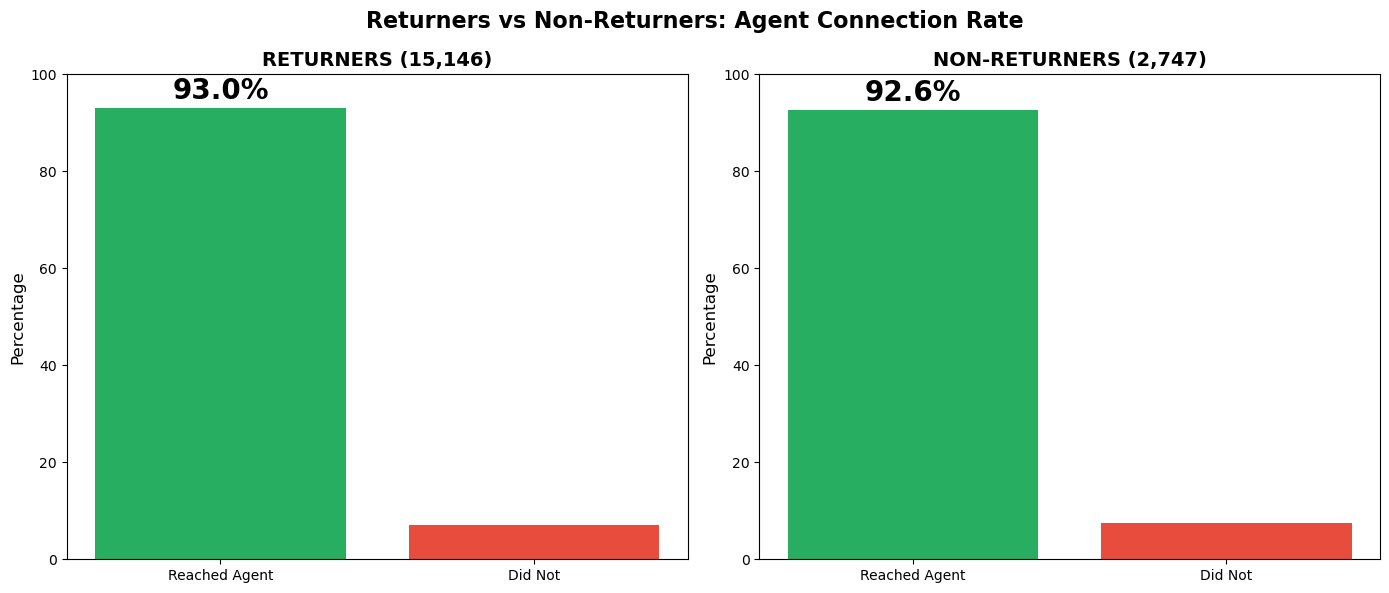

✅ Saved: returner_outcomes_breakdown.png


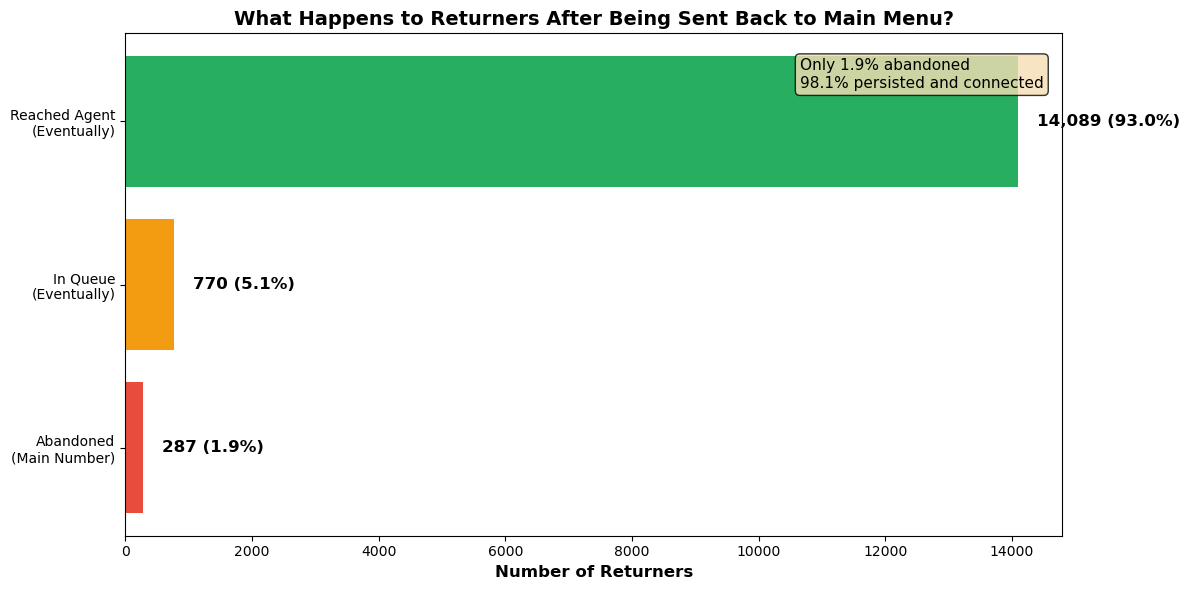

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# VISUAL 1: Agent Connection Rate Comparison
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Returners vs Non-Returners: Agent Connection Rate', 
             fontsize=16, fontweight='bold')

# Data
returner_rate = 93.0
non_returner_rate = 92.6

# Returners
ax1.bar(['Reached Agent', 'Did Not'], [returner_rate, 100-returner_rate], 
        color=['#27ae60', '#e74c3c'])
ax1.set_ylim(0, 100)
ax1.set_ylabel('Percentage', fontsize=12)
ax1.set_title('RETURNERS (15,146)', fontsize=14, fontweight='bold')
ax1.text(0, returner_rate + 2, f'{returner_rate}%', ha='center', fontsize=20, fontweight='bold')

# Non-Returners
ax2.bar(['Reached Agent', 'Did Not'], [non_returner_rate, 100-non_returner_rate],
        color=['#27ae60', '#e74c3c'])
ax2.set_ylim(0, 100)
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_title('NON-RETURNERS (2,747)', fontsize=14, fontweight='bold')
ax2.text(0, non_returner_rate + 2, f'{non_returner_rate}%', ha='center', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('returner_agent_connection_rate.png', dpi=300, bbox_inches='tight')
print("✅ Saved: returner_agent_connection_rate.png")
plt.show()

# ============================================================
# VISUAL 2: Outcome Categories
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Reached Agent\n(Eventually)', 'In Queue\n(Eventually)', 
              'Abandoned\n(Main Number)']
values = [14089, 770, 287]
percentages = [93.0, 5.1, 1.9]
colors = ['#27ae60', '#f39c12', '#e74c3c']

bars = ax.barh(categories, values, color=colors)

# Add value labels
for i, (bar, val, pct) in enumerate(zip(bars, values, percentages)):
    ax.text(val + 300, i, f'{val:,} ({pct}%)', 
            va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Number of Returners', fontsize=12, fontweight='bold')
ax.set_title('What Happens to Returners After Being Sent Back to Main Menu?', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add key insight box
textstr = 'Only 1.9% abandoned\n98.1% persisted and connected'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.72, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('returner_outcomes_breakdown.png', dpi=300, bbox_inches='tight')
print("✅ Saved: returner_outcomes_breakdown.png")
plt.show()



In [36]:

print("=" * 70)
print("⏱️  CALL DURATION COMPARISON: Returners vs Non-Returners")
print("=" * 70)

# Calculate duration for ALL sessions (both returners and non-returners)
all_durations = []

for session_id in df_return_analysis['Contact Session ID']:
    session_df = df_main[df_main['Contact Session ID'] == session_id].sort_values('Activity Start Timestamp')
    
    # Get return status
    returned = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Returned to Main Menu'].iloc[0]
    fd_type = df_return_analysis[df_return_analysis['Contact Session ID'] == session_id]['Front Desk Type'].iloc[0]
    
    # Calculate duration
    if len(session_df) > 0:
        first_timestamp = session_df.iloc[0]['Activity Start Timestamp']
        last_timestamp = session_df.iloc[-1]['Activity Start Timestamp']
        duration_seconds = (last_timestamp - first_timestamp).total_seconds()
        duration_minutes = duration_seconds / 60
        
        all_durations.append({
            'Contact Session ID': session_id,
            'Front Desk Type': fd_type,
            'Returned to Main Menu': returned,
            'Duration (seconds)': duration_seconds,
            'Duration (minutes)': duration_minutes,
            'Total Activities': len(session_df)
        })

df_durations = pd.DataFrame(all_durations)

# Quick comparison
returners_avg = df_durations[df_durations['Returned to Main Menu'] == True]['Duration (minutes)'].mean()
non_returners_avg = df_durations[df_durations['Returned to Main Menu'] == False]['Duration (minutes)'].mean()

print(f"Returners Average: {returners_avg:.2f} minutes")
print(f"Non-Returners Average: {non_returners_avg:.2f} minutes")
print(f"Difference: {returners_avg - non_returners_avg:.2f} minutes")

⏱️  CALL DURATION COMPARISON: Returners vs Non-Returners
Returners Average: 4.39 minutes
Non-Returners Average: 6.32 minutes
Difference: -1.93 minutes
